# <center>Challenge 1.2<center>

<p>Team Name:
<p>Student Names:

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [56]:
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# PART I

## Prepare Data

<b>A. Create a data sets with 100 data points with the following attributes (features) for two classes as such:</b>

b1 = normal distribution N(mean=40,var=16)<br>
b2 = normal distribution N(mean=40,var=4)<br>
Pr(b1,b2,LABEL) = {(b1, b2, 1)}, data objects with class positive<br>
P = Rotate(Pr,45), rotate Pr by 45 degrees in counter-clockwise<br>
Nr = Shift(Pr,b1,10), shift in b1-dimension by 10 units towards right, data objects with class negative. Nr(LABEL) = 0<br>
N = Rotate(Nr,45), rotate Nr by 45 degrees in counter-clockwise<br>
Merge Pr and Nr to get PNr, and P and N to obtain PN<br>

In [46]:
np.random.seed(0) # Create reproducible random values

#General variables
n = 100

# Generation of b1
b1_mean = 40
b1_var = 16
b1 = np.random.normal(loc=b1_mean, scale=np.sqrt(b1_var), size=n)

# Generation of b2
b2_mean = 40
b2_var = 4
b2 = np.random.normal(loc=b2_mean, scale=np.sqrt(b2_var), size=n)

# Create dataframe
D = pd.DataFrame({
    'b1' : b1,
    'b2' : b2
})


# print("Data Set D \n=========================")
# print(D)

In [47]:
def rotate(pts, degrees):
    radians = math.radians(degrees)
    R = []
    for b1, b2 in pts:
        rb1 = b1 * math.cos(radians) - b2 * math.sin(radians)
        rb2 = b1 * math.sin(radians) + b2 * math.cos(radians)
        R.append((rb1, rb2))
    #
    return R
#

def shift(pts, axis, shiftValue):
    S = []
    # Shift on b1 axis
    if axis == 'b1':
        for b1, b2 in pts:
            sb1 = b1 + shiftValue
            S.append((sb1, b2))
        #
    elif axis == 'b2':
        for b1, b2 in pts:
            sb2 = b2 + shiftValue
            S.append((b1, sb2))
        #
    else:
        print('Invalid axis provided to function shift().')
        sys.exit()
    #
    return S
    #
# Create Pr
Pr = D[['b1', 'b2']].copy()
Pr['label'] = '1'

# Create P
Pr_x = Pr[['b1', 'b2']].values
Pr_x_rotate = rotate(Pr_x, 45)
P = pd.DataFrame(Pr_x_rotate, columns=['b1', 'b2'])
P['label'] = '1'

# print("Data Set P \n=========================")
# print(P)


In [48]:
# Create Nr
Pr_x_shift = shift(Pr_x, 'b1', 10)
Nr = pd.DataFrame(Pr_x_shift, columns=['b1', 'b2'])
Nr['label'] = '0'

# Create N
Nr_x = Nr[['b1', 'b2']].values
Nr_x_rotate = rotate(Nr_x, 45)
N = pd.DataFrame(Nr_x_rotate, columns=['b1', 'b2'])
N['label'] = '0'


# print("Data Set Nr \n=========================")
# print(Nr)
# print("Data Set N \n=========================")
# print(N)

In [49]:
#Merge PN and NR to make PNR
PNr = pd.concat([Pr, Nr], ignore_index=True)

#Merge P and N to make PN
PN = pd.concat([P, N], ignore_index=True)
PN_df = pd.DataFrame(PN, columns=['b1', 'b2'])

# print("Data Set PNr \n=========================")
# print(PNr)
# print("Data Set PN \n=========================")
# print(PN)

<b>B. Scaling </b>

Apply scaling to PN by min-max to [0, 1], PN1:

In [50]:
scaler = MinMaxScaler()
PN1_np = scaler.fit_transform(PN[['b1', 'b2']])
PN1 = pd.DataFrame(PN1_np, columns=['b1','b2'])
PN1['label'] = PN['label'].values

# print(PN1)

Apply scaling to PN by min-max to [-1, 1], PN2:

In [51]:
scaler = MinMaxScaler(feature_range=(-1, 1))
PN2_np = scaler.fit_transform(PN[['b1', 'b2']])
PN2 = pd.DataFrame(PN2_np, columns=['b1','b2'])
PN2['label'] = PN['label'].values

# print(PN2)

Apply scaling to PN by std-normal, PN3:

In [52]:
scaler = StandardScaler()
PN3_np = scaler.fit_transform(PN[['b1', 'b2']])
PN3 = pd.DataFrame(PN3_np, columns=['b1', 'b2'])
PN3['label'] = PN['label'].values

# print(PN3)

## Visualize Data

Plot PNr, PN, PN1, PN2, PN3 in the same figure on a separate sub-plots of 2 by 3. The axis scale should be the same. The color of P\* and N\* will be green and blue, respectively. The shape of all data points will be circle:

# PART II - K-NN Classification

### A. Obtain 60% training dTrn, 20% validation dVal, 20% test dTst for each data set per class:

In [53]:
# Define ratio of training, validation, and test data points
pRatio = (0.6, 0.2, 0.2)

def getData(pInput,pRatio):
    '''
    pInput: data set to be split
    pRatio: ratio of training, validation, and test data points
    Returns dTrn, dVal, dTst
    '''
    # Need to do a 2-way data split twice. One split gives the training data set. The next split separates validation from test sets.
    pRatioTemp = pRatio[1] + pRatio[2]
    pTrn, pTemp = train_test_split(pInput, test_size=pRatioTemp, random_state=0) # First 2-way split, training set vs rest
    pRatioTemp = pRatio[2] / (pRatio[1] + pRatio[2])
    pVal, pTst = train_test_split(pTemp, test_size=pRatioTemp, random_state=0) # Second 2-way split, validation set vs test set

    # Convert to DataFrames
    trn_df = pd.DataFrame(pTrn)
    val_df = pd.DataFrame(pVal)
    tst_df = pd.DataFrame(pTst)
    
    return trn_df, val_df, tst_df
#

### B. Explore K-NN Classifiers

In [54]:
'''
Performance measures: Sensitivity, specificity, accuracy, F1

Define a function knnClassifier(pTrn, pVal, pTst, eps, *kwargs)
k = 1
Loop: Increase k by 1; k<len(pTrn)
   Generate Model
   Obtain contingency table based on validation data set
   Calculate accuracy over validation data set

   k = k + 1
   #
#
Plot accuracy-K chart

Find the best k-vaue.
For the best k-value:
   Obtain contingency table for testing data set
   Calculate performance measures for testing data set
   return (performance measures, contingency table)

'''

def knnClassifier(datasetName, pTrn, pVal, pTst, **kwargs):
    """
    Performs KNN classification, optimizes k, and calculates performance measures.

    Args:
        pTrn: Training data (Pandas DataFrame).
        pVal: Validation data (Pandas DataFrame).
        pTst: Testing data (Pandas DataFrame).
        **kwargs: Additional keyword arguments for KNN.

    Returns:
        A tuple containing performance measures and the contingency table for the best k.
    """

    # Data Preprocessing: Convert to NumPy arrays
    X_train, y_train = pTrn.iloc[:, :-1].values, pTrn.iloc[:, -1].values
    X_val, y_val = pVal.iloc[:, :-1].values, pVal.iloc[:, -1].values
    X_test, y_test = pTst.iloc[:, :-1].values, pTst.iloc[:, -1].values

    # Encode label classifications for computational efficiency
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train)
    y_val = encoder.transform(y_val)
    y_test = encoder.transform(y_test)

    # K Values
    k_values = range(1, len(X_train))
    accuracies = []

    # K Value Iteration
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan', **kwargs)
        knn.fit(X_train, y_train)
        y_pred_val = knn.predict(X_val)
        accuracies.append(accuracy_score(y_val, y_pred_val))
    #

    # Plot Accuracy-K Chart
    plt.plot(k_values, accuracies)
    plt.xlabel('K')
    plt.ylabel('Validation Accuracy')
    plt.title(f'{datasetName}: Accuracy vs. K')
    plt.savefig(f'{datasetName}_accuracy_vs_k_plot.png')  # Save the plot as an image
    plt.show()

    # Find Best K
    best_k = k_values[np.argmax(accuracies)]

    # Evaluate on Test Set
    knn_best = KNeighborsClassifier(n_neighbors=best_k, **kwargs)
    knn_best.fit(X_train, y_train)
    y_pred_test = knn_best.predict(X_test)

    # 6. Calculate Performance Measures
    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    confusion = confusion_matrix(y_test, y_pred_test)

    performance = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    return performance, confusion
#

def print_performance_and_confusion(performance, confusion):
    """
    Prints performance measures and confusion matrix with minimal labels.

    Args:
        performance (dict): Dictionary containing performance measures.
        confusion (np.ndarray): Confusion matrix.
    """

    print("PERFORMANCE MEASURES:")
    for key, value in performance.items():
        print(f"{key}: {value:.4f}")
    #

    print("\nCONTINGENCY TABLE")
    print(f"\tActual")
    print(f"Model\tT\tF")
    print(f"T\t{confusion[0][0]}\t{confusion[0][1]}")
    print(f"F\t{confusion[1][0]}\t{confusion[1][1]}")
#

### C. Run experiments for each data set {PNr, PN, PN1, PN2, PN3}

In [12]:
'''
For each data set {PNr, PN, PN1, PN2, PN3}
   Get training, validation, test data sets
   Run KNN for training and validation date sets
   Find the best model
   Obtain contingency table for the test data set
   Calculate performance measures for the test data set
'''

'\nFor each data set {PNr, PN, PN1, PN2, PN3}\n   Get training, validation, test data sets\n   Run KNN for training and validation date sets\n   Find the best model\n   Obtain contingency table for the test data set\n   Calculate performance measures for the test data set\n'

PNr


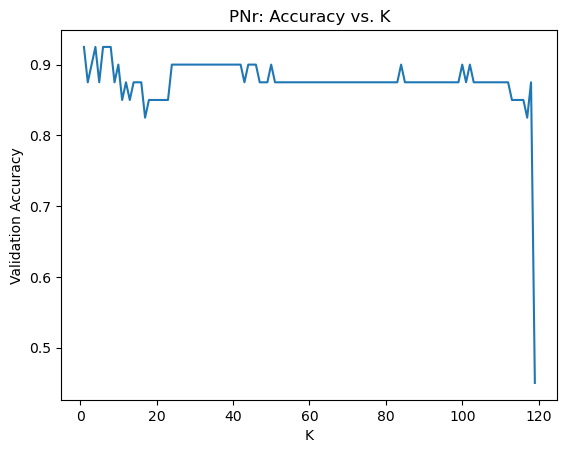

PERFORMANCE MEASURES:
accuracy: 0.8500
precision: 0.8543
recall: 0.8500
f1: 0.8500

CONTINGENCY TABLE
	Actual
Model	T	F
T	17	2
F	4	17
PN


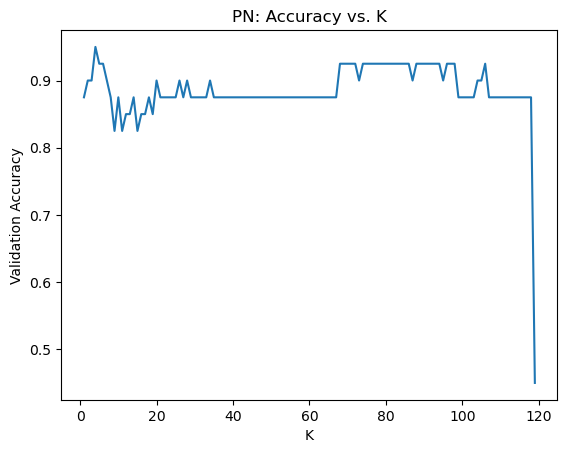

PERFORMANCE MEASURES:
accuracy: 0.9250
precision: 0.9262
recall: 0.9250
f1: 0.9250

CONTINGENCY TABLE
	Actual
Model	T	F
T	18	1
F	2	19
PN1


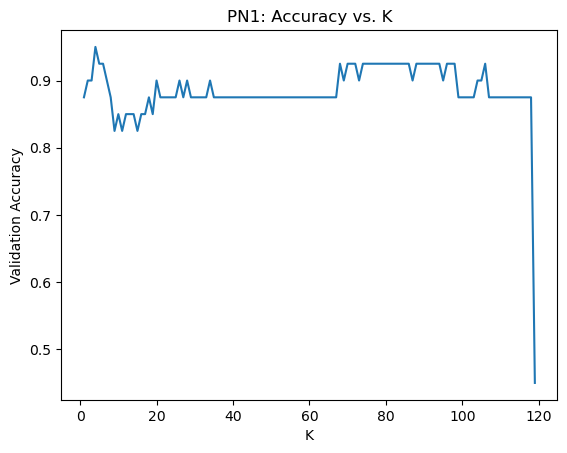

PERFORMANCE MEASURES:
accuracy: 0.9250
precision: 0.9262
recall: 0.9250
f1: 0.9250

CONTINGENCY TABLE
	Actual
Model	T	F
T	18	1
F	2	19
PN2


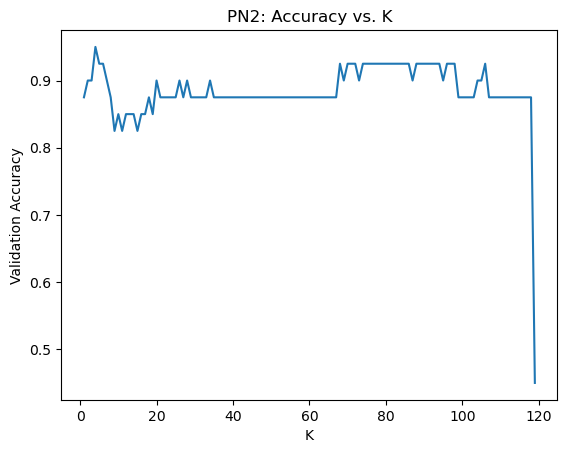

PERFORMANCE MEASURES:
accuracy: 0.9250
precision: 0.9262
recall: 0.9250
f1: 0.9250

CONTINGENCY TABLE
	Actual
Model	T	F
T	18	1
F	2	19
PN3


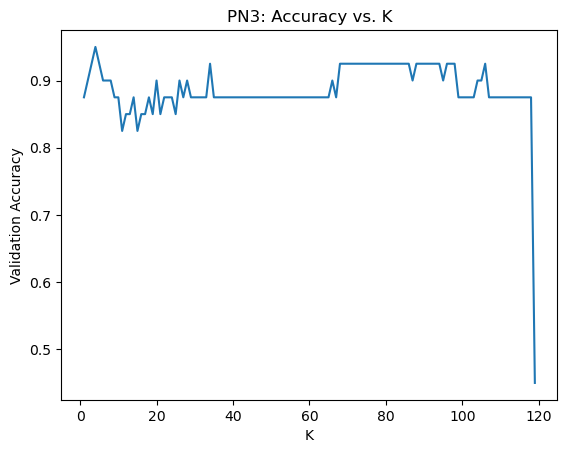

PERFORMANCE MEASURES:
accuracy: 0.8500
precision: 0.8543
recall: 0.8500
f1: 0.8500

CONTINGENCY TABLE
	Actual
Model	T	F
T	17	2
F	4	17


In [57]:
'''
For each data set {PNr, PN, PN1, PN2, PN3}
   Get training, validation, test data sets
   Run KNN for training and validation date sets
   Find the best model
   Obtain contingency table for the test data set
   Calculate performance measures for the test data set
'''

# For PNr
print("=============================================================================")
print("PNr")
print("=============================================================================")
PNr_trn, PNr_val, PNr_tst = getData(PNr, pRatio)
PNr_performance, PNr_confusion =  knnClassifier('PNr', PNr_trn, PNr_val, PNr_tst)
print_performance_and_confusion(PNr_performance, PNr_confusion)

# For PN
print("=============================================================================")
print("PN")
print("=============================================================================")
PN_trn, PN_val, PN_tst = getData(PN, pRatio)
PN_performance, PN_confusion =  knnClassifier('PN', PN_trn, PN_val, PN_tst)
print_performance_and_confusion(PN_performance, PN_confusion)

# For PN1
print("=============================================================================")
print("PN1")
print("=============================================================================")
PN1_trn, PN1_val, PN1_tst = getData(PN1, pRatio)
PN1_performance, PN1_confusion =  knnClassifier('PN1', PN1_trn, PN1_val, PN1_tst)
print_performance_and_confusion(PN1_performance, PN1_confusion)

# For PN2
print("=============================================================================")
print("PN2")
print("=============================================================================")
PN2_trn, PN2_val, PN2_tst = getData(PN2, pRatio)
PN2_performance, PN2_confusion =  knnClassifier('PN2', PN2_trn, PN2_val, PN2_tst)
print_performance_and_confusion(PN2_performance, PN2_confusion)

# For PN3
print("=============================================================================")
print("PN3")
print("=============================================================================")
PN3_trn, PN3_val, PN3_tst = getData(PN3, pRatio)
PN3_performance, PN3_confusion =  knnClassifier('PN3', PN3_trn, PN3_val, PN3_tst)
print_performance_and_confusion(PN3_performance, PN3_confusion)

### D. Visualize Results

<b>Plot training (shape: Circle) and test (shape: Triangle) data sets of {PNr, PN, PN1, PN2, PN3} on a separate sub-plot in the same figure:</b>

In [13]:
def plotSets():
    pass
#

<b>Plot accuracy-K charts for each data set (P\*, N\*) on a separate sub-plot in the same figure:</b>

In [14]:
def plotKChart():
    pass
#

<b>Plot sensitivity, specificity, accuracy, and F1 of the best KNN-C for each data set (P\*, N\*) on a separate sub-plot in the same figure:</b> Hint: There will be 4 sup-plots with a bar-chart.

In [15]:
def plotPerform():
    pass
#

# PART III - Discussion
Discuss how scaling affects the classification performance of K-NN classifier based on each performance measures

## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.